In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/clean_data.csv')

In [7]:
data = data.drop(columns=('Unnamed: 0'))
cols = data.columns
cols

Index(['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age', 'genre_blues', 'genre_country',
       'genre_hip hop', 'genre_jazz', 'genre_pop', 'genre_reggae',
       'genre_rock'],
      dtype='object')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


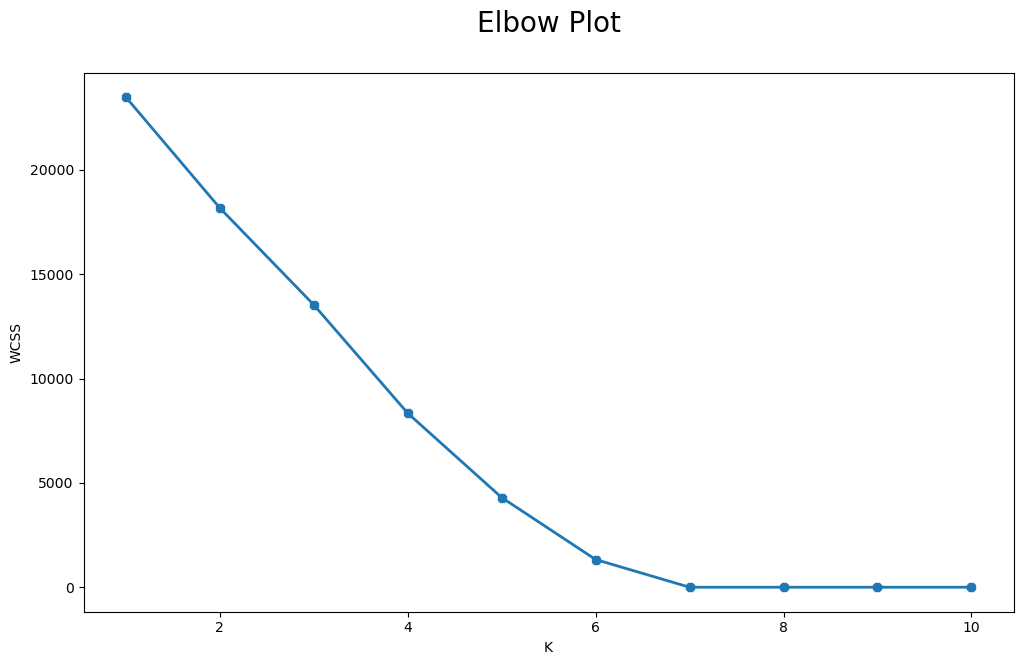

In [8]:
X1 = data.loc[:, ['genre_blues', 'genre_country',
       'genre_hip hop', 'genre_jazz', 'genre_pop', 'genre_reggae',
       'genre_rock']].values

wcss= []
for k in range(1, 11):
    # TODO: create a Kmeans object initialized with `k` clusters and `init` parameter of `k-means++`
    # DOCUMENTATION: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

plt.figure(figsize = (12, 7))

plt.plot(range(1, 11), wcss, linewidth = 2, marker = '8')
plt.title('Elbow Plot\n', fontsize = 20)
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


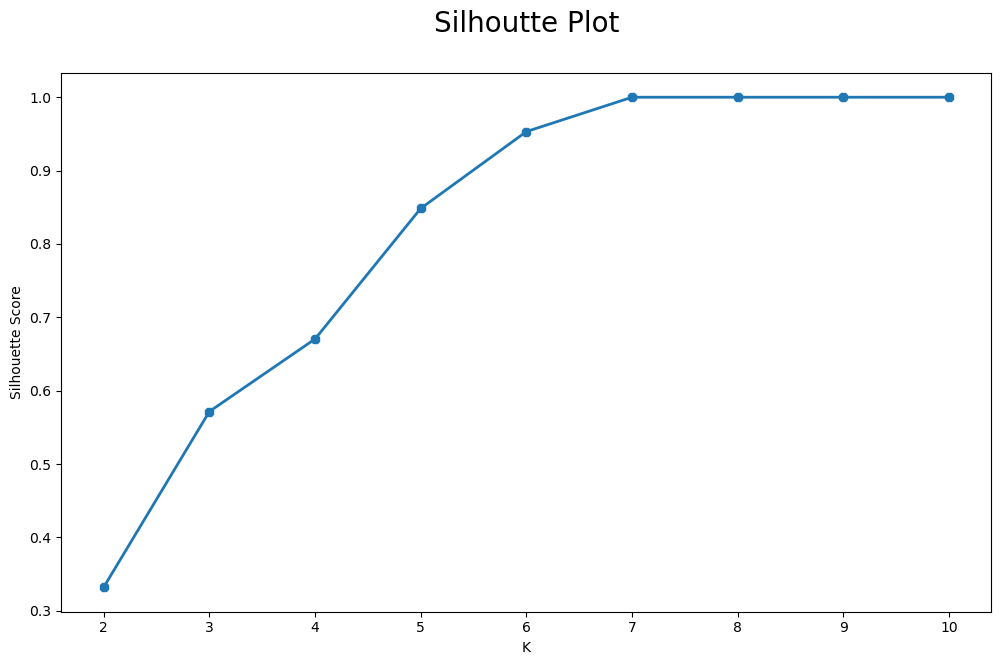

In [9]:
silhouette = []
for k in range(2, 11):
    # TODO: create a Kmeans object initialized with `k` clusters and `init` parameter of `k-means++`
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    predictions = kmeans.fit_predict(X1)
    silhouette.append(metrics.silhouette_score(X1, predictions))

plt.figure(figsize = (12, 7))

plt.plot(range(2, 11), silhouette, linewidth = 2, marker = '8')
plt.title('Silhoutte Plot\n', fontsize = 20)
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

In [23]:
k_means = KMeans(n_clusters=7, init='k-means++')
k_means.fit(X1)

KMeans(n_clusters=7)

In [26]:
# output the centroids of clusters
labels = k_means.fit_predict(X1)
labels
k_means.cluster_centers_

array([[-1.80411242e-15,  7.13318293e-15,  5.55111512e-17,
         2.83106871e-15,  1.34336986e-14, -2.28983499e-15,
         1.00000000e+00],
       [-1.07414078e-14, -4.71844785e-15,  2.41473508e-15,
         2.99760217e-15,  1.00000000e+00,  1.80411242e-15,
        -8.54871729e-15],
       [ 1.00000000e+00,  6.68909372e-15,  5.41233725e-16,
         2.85882429e-15,  1.52655666e-14, -2.53963517e-15,
        -1.30451205e-15],
       [-6.30051566e-15,  1.85962357e-15,  1.26287869e-15,
         1.00000000e+00,  1.41830991e-14, -1.45716772e-15,
        -4.35762537e-15],
       [-6.68909372e-15,  1.00000000e+00,  1.46410661e-15,
         2.85882429e-15,  1.65423231e-14,  8.18789481e-16,
        -4.41313652e-15],
       [-3.60822483e-16,  4.91273688e-15, -5.27355937e-16,
         2.55351296e-15,  9.71445147e-15,  1.00000000e+00,
         2.30371278e-15],
       [ 2.77555756e-15,  1.63757896e-15,  1.00000000e+00,
         2.33146835e-15, -4.16333634e-16,  1.11022302e-16,
         2.7200464

In [28]:
# view 2D clusters

plt.figure(figsize = (14, 8))

plt.scatter(X1[:, 0], X1[:, 1], c = kmeans.labels_, s = 105)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color = 'red', s = 250)
plt.title('Clusters of Customers\n', fontsize = 20)
plt.show()

AttributeError: 'int' object has no attribute 'labels_'

<Figure size 1400x800 with 0 Axes>